# HyperParameterOptimisation for Approval Predict

## Imports and required libraries

In [1]:
# Core
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Sklearn: split, metrics, model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, make_scorer
)

# Preprocessing & Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from feature_engine.transformation import BoxCoxTransformer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier
)
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

## Update Working Directory

In [2]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict/jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict'

## Load data

In [5]:
root = os.getcwd()
file_path = Path(root) / "outputs" / "datasets" / "collection" / "loan_approval.csv"
df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)

df['loan_approved'] = df['loan_approved'].astype(int)

reduced_features = ['years_employed', 'loan_amount']
X = df[reduced_features].copy()
y = df['loan_approved'].copy()

X.head(3), y.head(3)

(   years_employed  loan_amount
 0              27        39698
 1              28        15446
 2              13        11189,
 0    0
 1    0
 2    0
 Name: loan_approved, dtype: int64)

## Split train and test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Shapes:")
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Train/Test Shapes:


((1600, 2), (1600,), (400, 2), (400,))

## Handle Class Imbalance

After SMOTE: (1808, 2) (1808,)


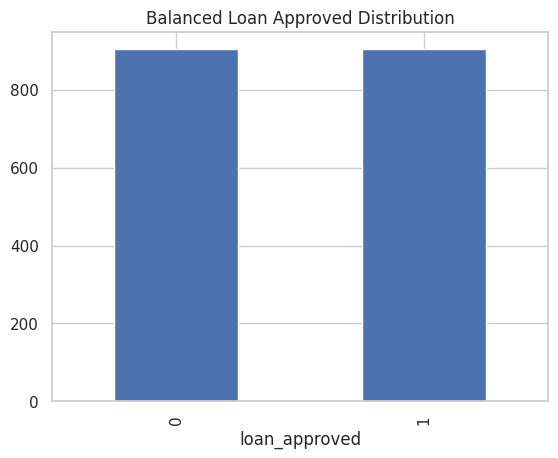

In [7]:
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(kind='bar', title='Balanced Loan Approved Distribution')
plt.show()

## ML Pipeline

In [8]:
def PipelineClf(model):
    return Pipeline([
        ("scaler", RobustScaler()),
        ("model", model)
    ])

In [9]:
def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation that includes
    feature transformations, robust scaling and a classifier model.
    """
    return Pipeline([
        ("scaler", RobustScaler()),
        ("model", model),
    ])

## HyperParameter Optimisation

In [10]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

In [11]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=prediction, y_pred=y),
        columns=[["Actual " + sub for sub in label_map]],
        index=[["Prediction " + sub for sub in label_map]]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

First round of hyperparameter optimisation using AdaBoostClassifier

In [12]:
model = {"AdaBoostClassifier": AdaBoostClassifier(random_state=42)}

https://www.youtube.com/watch?v=JmXnztjULnQ 
Tune its key parameters (such as n_estimators and learning_rate) to improve its generalisation.
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
Scikit-learn details default parameters of 50 for n_estimators and 1 for learning rate. I adjusted these values

In [13]:
params_search = {
    "AdaBoostClassifier": {
        "model__n_estimators": [50, 100, 150, 200],
        "model__learning_rate": [0.25, 0.5, 1]
    }
}

n_estimators: Number of trees in the ensemble. How many small trees the model builds and combines to make predictions.
learning_rate: Weight of each tree’s contribution. How strongly each tree changes the model’s final prediction.

In [14]:
search = HyperparameterOptimizationSearch(models=model, params=params_search)
search.fit(X_train_bal, y_train_bal,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [15]:
extensive_grid_search_summary, extensive_grid_search_pipelines = search.score_summary(sort_by='mean_score')

best_model = extensive_grid_search_summary.iloc[0,0]
best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = extensive_grid_search_pipelines[best_model].best_estimator_

best_parameters

{'model__learning_rate': 0.25, 'model__n_estimators': 200}

In [16]:
clf_performance(X_train=X_train, y_train=y_train,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             534             256
Prediction Approved             370             440


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.68      0.59      0.63       904
    Approved       0.54      0.63      0.58       696

    accuracy                           0.61      1600
   macro avg       0.61      0.61      0.61      1600
weighted avg       0.62      0.61      0.61      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             128              61
Prediction Approved              89             122


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.68      0.59      0.63       217
    Approved       0.58      0.67      0.62       183

    accuracy                   